# How do computers hear music?

For a computer to process music, we have to first *digitize* the music information. If we are talking about graphics, *digitization* refers to the process of the real-life image that our eyes can see being captured by cameras into pixels, which are represented by a matrix of colour dots, to be displayed on a screen or stored as a file.

Sound comes from **vibration of particles** in air or other media. When our ears capture the vibration energy, the brain hears something. Digitized sounds are measured as *samples*, which basically record the vibration amplitude of certain moments. When we need to replay a sound file in the computer, vibrating the loudspeaker diaphragm with this amplitude would re-create the sound.

![Sounds come from vibrations](https://miro.medium.com/max/1400/1*MLfPicYZWwswHx4-fvfhFA.png)

There are two *general* requirements for the vibration to be heard:

1. _Periodic_: The vibration should be rather repetitive, with a certain frequency. The frequency is usually measued as times per second. Once per second is named **1 Hertz**, or abbreviated as **1 Hz**.

2. Within _human audible range_: Human ears can hardly perceive frequencies under 20 Hz as a sound, but instead as some vibrations felt in the human body. Above around 15,000 Hz (15 kHz), the frequency perception becomes less sensitive, which especially declines with age.

There are usually periodic sounds in music, with a not-so-short duration (at least around 0.1 second) and a certain frequency, referred to as a pitched sound. A higher frequency gives a higher pitch. The tuning pitch *A440* in orchestras is the standard A note at 440 Hz. Let's look only at pitched sounds first.

## Audio representation

The "*purest*" sound is a sine wave — we'll look at more complex sounds later. Here is a **1-second 440 Hz pure sound**, created with Python code. Play and hear it.

In [11]:
import IPython.display as ipd
import numpy

sr = 22050  # Sampling rate (Hz)
f = 440  # Frequency (Hz)
tmax = 1  # Duration (s)

### Construct a time line
t = numpy.linspace(0, tmax, sr * tmax)
### Construct the audio signal data
x = numpy.sin(2 * numpy.pi * f * t)
### Show the sound in audio player
ipd.Audio(x, rate=sr)


*Python programming is popular these days!* We will demo most of our code in Python.

So what does this code do? Basically, `t` is a timeline, with a value from `0` to `tmax` (`1`) in very small increments. `x` is the value of the sine wave at this time (`t`), calculated with the formula *2πft*, ranging from `-1` to `1`. Here shows the contents of the first 100 samples.

> *Oopsie isn't this too hard?? More on programming later...*

In [12]:
import pandas as pd
df = pd.DataFrame(
    {
        "t": t[0:220],
        "x": x[0:220],
    }
)
### Here the data only shows first 220 frames (0.01s) of the audio data
df

,t,x
0,0.000000,0.000000
1,0.000045,0.125056
2,0.000091,0.248149
3,0.000136,0.367345
4,0.000181,0.480774
...,...,...
215,0.009751,0.967886
216,0.009796,0.928849
217,0.009842,0.875230
218,0.009887,0.807868


Okay, how does it look? Here is the "sound" zoomed-in a lot... that the chart only shows *0.01 s of the waveform*.

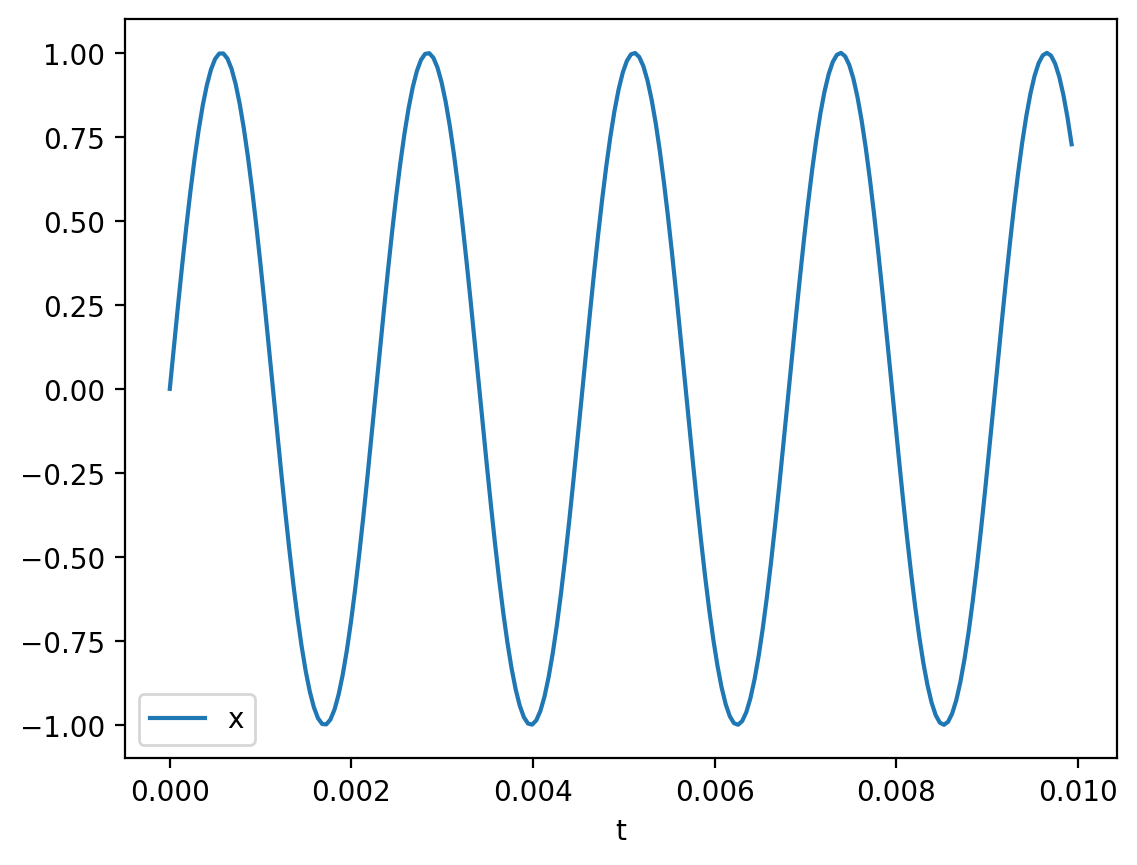

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# gca stands for 'get current axis'
ax = plt.gca()

df.plot(kind='line',x='t',y='x',ax=ax)

plt.show()

Here is how the whole 1-second sound looks — doesn't look like the usual waveform seen in recording apps ***at all***! Do not forget, this is a plain pure sound that has no change in dynamics and pitch. Digitized sounds are really nothing more than lots of 0 → 1 → 0 → -1 → 0 → … （or occassionally something like 0–65536 in some representations).

In [14]:
import pandas as pd
df2 = pd.DataFrame(
    {
        "t": t,
        "x": x,
    }
)
### Here the data only shows first 220 frames (0.01s) of the audio data
df2

,t,x
0,0.000000,0.000000e+00
1,0.000045,1.250562e-01
2,0.000091,2.481489e-01
3,0.000136,3.673455e-01
4,0.000181,4.807745e-01
...,...,...
22045,0.999819,-4.807745e-01
22046,0.999864,-3.673455e-01
22047,0.999909,-2.481489e-01
22048,0.999955,-1.250562e-01


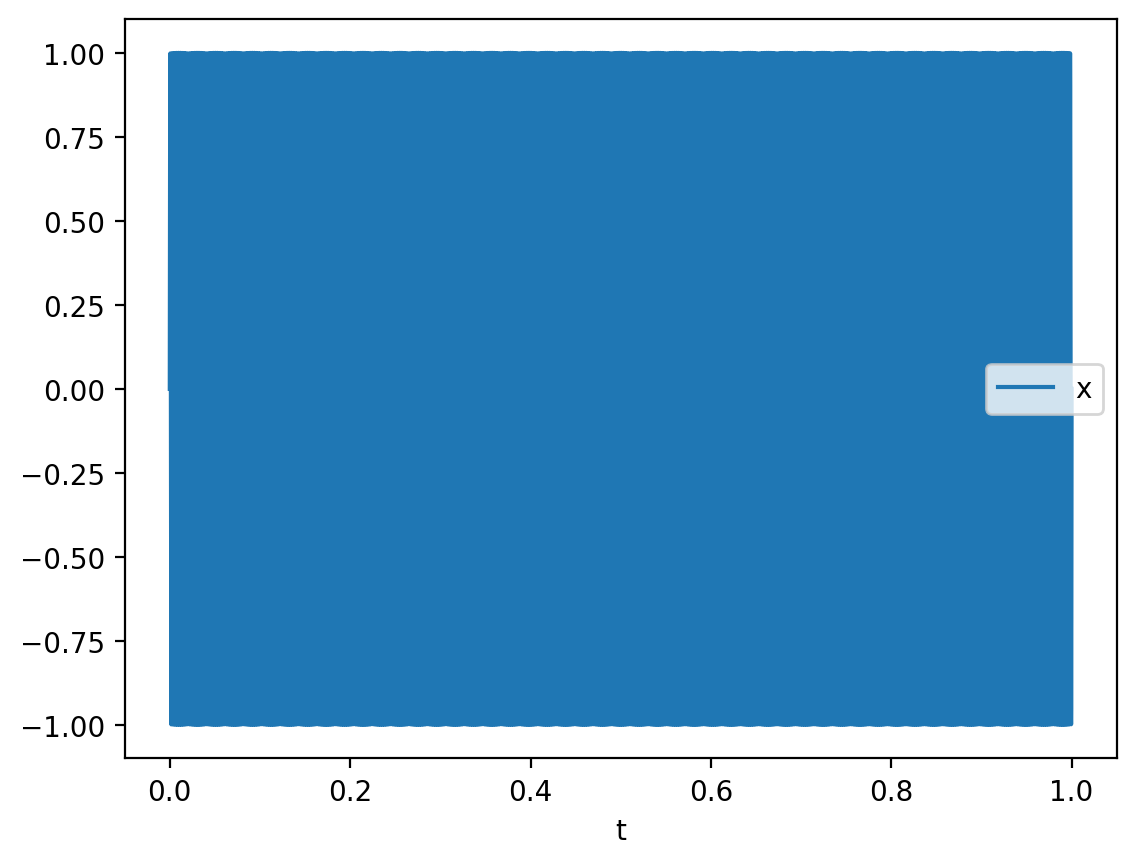

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# gca stands for 'get current axis'
ax = plt.gca()

df2.plot(kind='line',x='t',y='x',ax=ax)

plt.show()

## Symbolic representation

When the complete sound is recorded, it's usually convenient for replaying. No matter what kind of instruments, or how the acoustics are, everything is faithfully represented given that you have a *reliable recording team*. Yet, much of the low-level data is simply too complex for musicians, giving rise to the ***symbolic representation*** of sounds. We only need information like pitch, duration, dynamics, and instruments etc.

Many electronic/digital instruments in the market support well the standard of *Musical Instrument Digital Interface* (MIDI). It originated in 1982 as MIDI 1.0, and the release of MIDI 2.0 in 2020 was quite a hype for (electronic) musicians.

The MIDI format didn't change a lot since the 80's, with basic messages as "*note on/off—note number—velocity*". The note number (pitch) is an 8-bit number, i.e. a value of 0–127. It can correspond to every standard pitch in Western classical music. For example, MIDI number 60 represents the Middle C on the piano.

![MIDI pitch numbers corresponding to piano keys](https://miro.medium.com/max/1400/1*u7_J1rYCr_ZRjbSCVN8Xig.png)

Here the Python code uses MIDI note numbers to notate music. `melody` has the pitches we want, and they are put one by one into `s` (the `Stream`). You can see the generated *boring* phrase of music with default duration and dynamics. Play and hear it!

In [16]:
# !pip install --upgrade music21
# !add-apt-repository ppa:mscore-ubuntu/mscore-stable -y
# !apt-get update
# !apt-get install musescore

from music21 import *
us = environment.UserSettings()
us['musescoreDirectPNGPath'] = '/usr/bin/mscore'
us['directoryScratch'] = '/tmp'

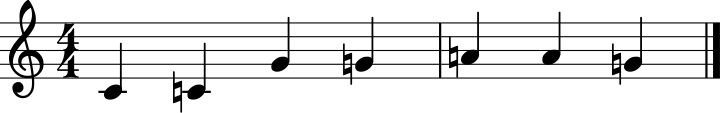

In [17]:
from music21 import *
s = stream.Stream()
melody = [60,60,67,67,69,69,67,]
for p in melody:
    s.append(note.Note(p))
s.show()
s.show('midi')
#s.show('lily.png')
#s.write('lily.png')
#Image(filename=s.write('lily.png'))

MIDI comes with simple musical commands only and occupies only small storage on a computer. A decent MIDI sequencer with a good MIDI player would make the listening experience... *acceptable*. Before the wave of MP3 files brought by broadband Internet, MIDI files were what people have in their music collection on their home computer. At that time Windows/Mac had MIDI players in the system for simple music playing.

Although MIDI files are no longer commonplace in home computers, the format is still widely used in music production software, such as in software instruments in Apple software, or score-making software like MuseScore. They often rely heavily on symbolic representated sounds for easy editing.

![The same melody in Logic Pro represented as symbols (top) and audio (bottom)](https://cdn-images-1.medium.com/max/1600/1*7BmoVjl0BPMykbNOIqkb7g.png)

---

Audio representation and symbolic representation are good for different purposes. While audio representation gives a faithful record, editing is not trivial. Symbolic representation relies on the playing system for re-creating the sound, is great for music editing but not for non-instrumental sounds (e.g. human voice!). It's not difficult for converting a symbolic file to audio, by just playing it through. Yet the reverse is still a research problem in computer music — *Automatic Music Transcription* (AMT).

Let's talk about other interesting tidbits of the two in another notebook later.

References:
- https://colab.research.google.com/gist/mscuthbert/431dee45c01598a0c11bc27823bd1c5b/music21_setup.ipynb#scrollTo=CP91XD_o8nr4
- https://colab.research.google.com/drive/17Fql7pyK3xsO8KmZorvb1tBoPomidCPB#scrollTo=hKDhJGQVqb3Y